# CCO13: Jie

In [17]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib as plt
import scanpy as sc
import anndata as ad

In [185]:
WORK_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO13"
DATA_DIR = "/home/herbert/PyProjects/cocultured_organ/data/260402"

In [6]:
os.system(f"mkdir -p {WORK_DIR}")

0

# 0. Data

In [29]:
os.system(f"mkdir -p {WORK_DIR}/adata/raw")

0

In [120]:
os.system(f"ls -l {DATA_DIR}/*.h5")

-rw-r--r-- 1 herbert yachilab 21022207 Jul 28 09:34 /home/herbert/PyProjects/cocultured_organ/data/260402/OCM2-AFENC8-JJ-022626-R.h5
-rw-r--r-- 1 herbert yachilab  3825822 Jul 28 09:46 /home/herbert/PyProjects/cocultured_organ/data/260402/OCM2-AFEWTC-JJ-022626-B.h5
-rw-r--r-- 1 herbert yachilab  6943525 Jul 28 09:46 /home/herbert/PyProjects/cocultured_organ/data/260402/OCM2-IPSNC8-JJ-022626-G.h5
-rw-r--r-- 1 herbert yachilab  2735413 Jul 28 09:47 /home/herbert/PyProjects/cocultured_organ/data/260402/OCM2-IPSWTC-JJ-022626-Y.h5


0

In [131]:
adata_all = None

for f in glob.glob(f"{DATA_DIR}/*.h5"):
    batch = f.split("/")[-1].split("-")[0]
    cell_line = f.split("/")[-1].split("-")[1]

    adata = sc.read_10x_h5(f)
    adata.var_names_make_unique()
    adata.obs["batch"] = batch
    adata.obs["cell_line"] = cell_line
    
    if adata_all is None:
        adata_all = adata
    else:
        adata_all = ad.concat([adata_all, adata])

adata_all.write(f"{WORK_DIR}/adata/raw/ALL.h5ad")

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarn

# 1. preprocessing

In [183]:
os.system(f"mkdir -p {WORK_DIR}/adata/processed")

0

In [169]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/raw/ALL.h5ad")

In [170]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True)

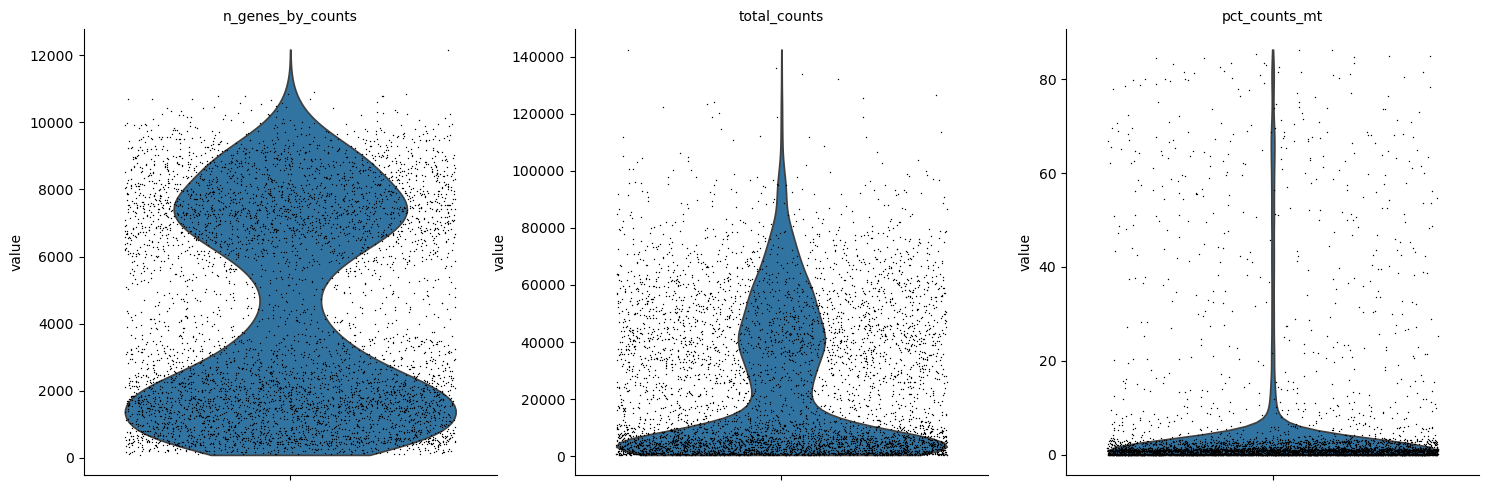

In [171]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

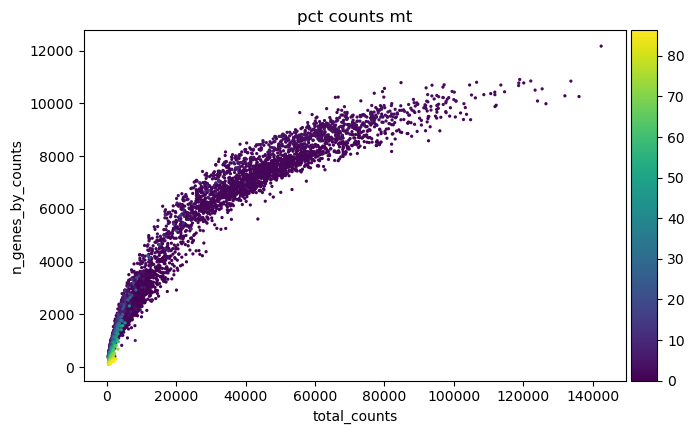

In [172]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [173]:
n_old = adata.n_obs

adata = adata[adata.obs["pct_counts_mt"] < 5]
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

print(f"removed due to mito percent or count: {n_old - adata.n_obs}")

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:139: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number


removed due to mito percent or count: 595


In [174]:
n_old = adata.n_obs

sc.external.pp.scrublet(adata, batch_key="batch", random_state=42)
adata = adata[np.logical_not(adata.obs["predicted_doublet"])]

print(f"removed due to doublet: {n_old - adata.n_obs}")

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:250: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var['n_cells'] = number
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Automatically set threshold at doublet score = 0.44
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 11.8%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.0%
removed due to doublet: 0


In [175]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [176]:
sc.tl.pca(adata, n_comps=100, random_state=42, svd_solver="arpack")
sc.pp.neighbors(adata, n_neighbors=1000, n_pcs=100, random_state=42)
sc.tl.leiden(adata, resolution=0.5, random_state=42)
sc.tl.umap(adata, random_state=42)

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


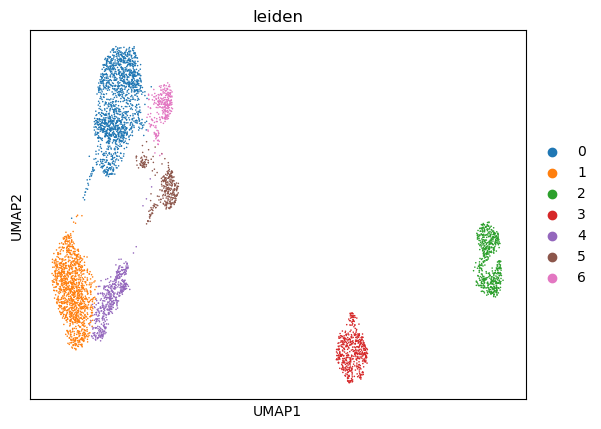

In [177]:
sc.pl.umap(adata, color="leiden", s=5)

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


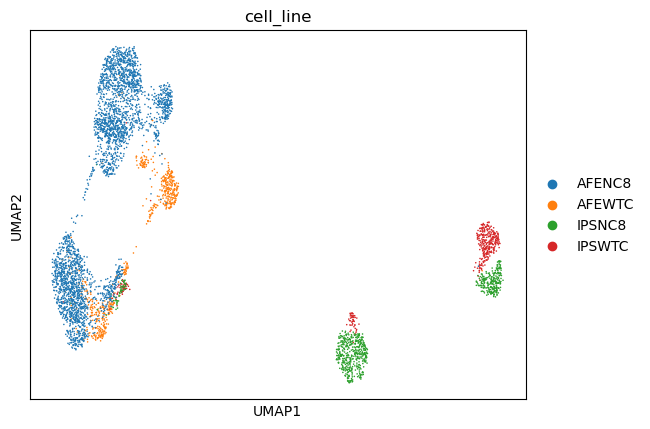

In [178]:
sc.pl.umap(adata, color="cell_line", s=5)

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


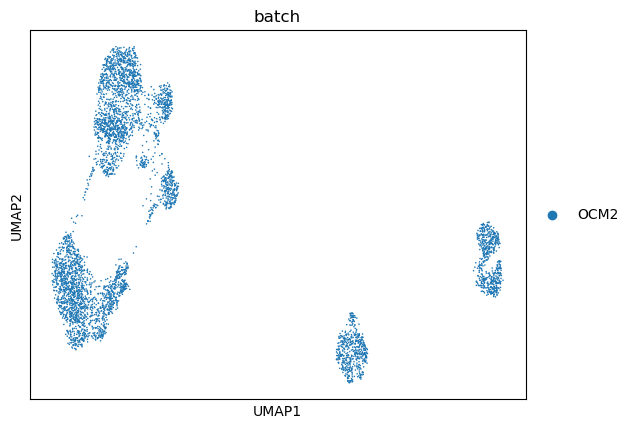

In [179]:
sc.pl.umap(adata, color="batch", s=5)

In [181]:
adata.obs = adata.obs[["batch", "cell_line", "leiden"]]

In [184]:
adata.write(f"{WORK_DIR}/adata/processed/ALL.h5ad")